In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# This source code is licensed under the MIT license found in the
# LICENSE file in the root directory of this source tree.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# res = pd.read_csv('Results_Syn/Simulation_Concept_Covariate_TLCQM_Abla1.csv')
res = pd.read_csv('Results_Syn/Simulation_Concept_Covariate_TLCQM_Conditional_Mean_Abla.csv')
res['source_target_ratio'] = res['source_size'] / res['target_size']
# res.groupby(['Method', 'source_target_ratio']).mean().reset_index().to_csv('sim_abla.csv', index=False)
res = res[(res["Metric"] != 'AvgPinball') & (res["Metric"] != 'CRPS')]
res.groupby(['Method', 'Metric', 'source_target_ratio']).mean().reset_index().to_csv('sim_abla_conditional_mean.csv', index=False)

a = res.groupby(['Method', 'Metric', 'source_target_ratio']).mean().reset_index()
a

,Method,Metric,source_target_ratio,Value,source_size,target_size
0,Engression_Only,KRR,1.0,0.757207,100.0,100.0
1,Engression_Only,KRR,2.0,0.959150,200.0,100.0
2,Engression_Only,KRR,5.0,1.368566,500.0,100.0
3,Engression_Only,KRR,10.0,1.816318,1000.0,100.0
4,Engression_Only,KRR,15.0,2.156094,1500.0,100.0
...,...,...,...,...,...,...
107,TLCQM_Conditional,XGBoost,5.0,0.307598,500.0,100.0
108,TLCQM_Conditional,XGBoost,10.0,0.304324,1000.0,100.0
109,TLCQM_Conditional,XGBoost,15.0,0.302620,1500.0,100.0
110,TLCQM_Conditional,XGBoost,20.0,0.302219,2000.0,100.0


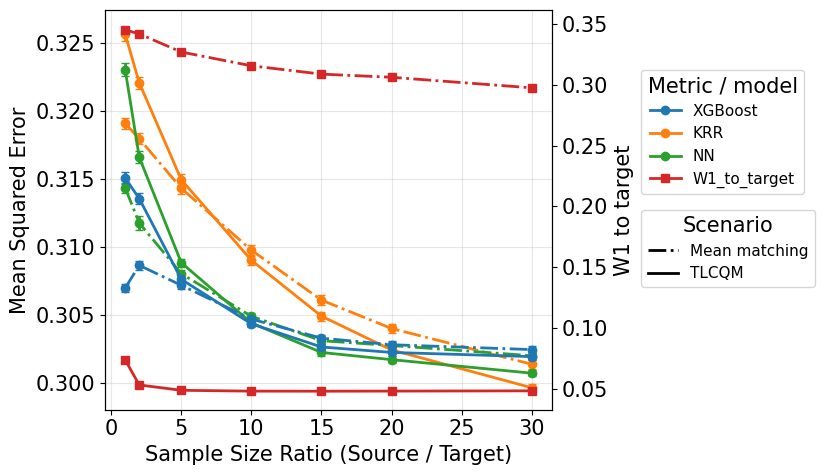

In [10]:
from matplotlib.lines import Line2D

plt.rcParams.update({'font.size': 15})

summary = (
    res
    .groupby(["Method", "Metric", "source_target_ratio"])
    .agg(
        mean_value=("Value", "mean"),
        se_value=("Value", lambda x: x.std(ddof=1) / np.sqrt(len(x)))
    )
    .reset_index()
)

# ---- rename columns to match plotting logic ----
summary = summary.rename(columns={
    "Method": "Scenario",
    "Metric": "MetricName"
})

# ---- prettier scenario names ----
scenario_name_map = {
    "Engression_Only": "Engression only",
    "Mean_Matching": "Mean matching",
    "OT_Calibration": "OT calibration",
    "TLCQM_Conditional": "TLCQM"
}
summary["Scenario"] = summary["Scenario"].replace(scenario_name_map)

# ---- keep only scenarios you want ----
summary = summary[summary["Scenario"].isin(["Mean matching", "TLCQM"])].copy()

# ---- split metrics ----
mse_metrics = ["XGBoost", "KRR", "NN"]
w1_metric = "W1_to_target"

summary_mse = summary[summary["MetricName"].isin(mse_metrics)].copy()
summary_w1 = summary[summary["MetricName"] == w1_metric].copy()

# ---- color & linestyle maps ----
color_map = {
    "XGBoost": "tab:blue",
    "KRR": "tab:orange",
    "NN": "tab:green",
    "W1_to_target": "tab:red"
}

linestyle_map = {
    "Mean matching": "-.",
    "TLCQM": "-"
}

marker_map = {
    "XGBoost": "o",
    "KRR": "o",
    "NN": "o",
    "W1_to_target": "s"
}

# ---- plot with twin y-axis ----
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

# ---- MSE curves on left axis ----
for (metric, scenario), sub in summary_mse.groupby(["MetricName", "Scenario"]):
    sub = sub.sort_values("source_target_ratio")
    ax1.errorbar(
        sub["source_target_ratio"],
        sub["mean_value"],
        yerr=sub["se_value"],
        color=color_map[metric],
        linestyle=linestyle_map[scenario],
        marker=marker_map[metric],
        linewidth=2,
        capsize=3
    )

# ---- W1 curves on right axis ----
for scenario, sub in summary_w1.groupby("Scenario"):
    sub = sub.sort_values("source_target_ratio")
    ax2.errorbar(
        sub["source_target_ratio"],
        sub["mean_value"],
        yerr=sub["se_value"],
        color=color_map["W1_to_target"],
        linestyle=linestyle_map[scenario],
        marker=marker_map["W1_to_target"],
        linewidth=2,
        capsize=3
    )

# ---- legends ----
metric_handles = [
    Line2D([0], [0], color=color_map[m], lw=2, marker=marker_map[m], label=m)
    for m in ["XGBoost", "KRR", "NN", "W1_to_target"]
]

scenario_handles = [
    Line2D([0], [0], color="black", lw=2,
           linestyle=linestyle_map[s], label=s)
    for s in ["Mean matching", "TLCQM"]
]

legend_metric = ax1.legend(
    handles=metric_handles,
    title="Metric / model",
    loc="upper left",
    bbox_to_anchor=(1.2, 0.85),
    borderaxespad=0.0,
    fontsize=11
)

legend_scenario = ax1.legend(
    handles=scenario_handles,
    title="Scenario",
    loc="upper left",
    bbox_to_anchor=(1.2, 0.50),
    borderaxespad=0.0,
    fontsize=11
)

ax1.add_artist(legend_metric)

# ---- labels & formatting ----
ax1.set_xlabel("Sample Size Ratio (Source / Target)")
ax1.set_ylabel("Mean Squared Error")
ax2.set_ylabel("W1 to target")

ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
summary

,Scenario,MetricName,source_target_ratio,mean_value,se_value
28,Mean matching,KRR,1.0,0.319066,0.000388
29,Mean matching,KRR,2.0,0.317942,0.000400
30,Mean matching,KRR,5.0,0.314297,0.000400
31,Mean matching,KRR,10.0,0.309744,0.000395
32,Mean matching,KRR,15.0,0.306069,0.000355
33,Mean matching,KRR,20.0,0.303980,0.000350
34,Mean matching,KRR,30.0,0.301354,0.000323
35,Mean matching,NN,1.0,0.314314,0.000394
36,Mean matching,NN,2.0,0.311742,0.000505
37,Mean matching,NN,5.0,0.308015,0.000297


In [24]:
res_diag = pd.read_csv("./Results_Syn/Simulation_TLCQM_Conditional_Mean_Diagnostic.csv")
res_diag = res_diag[['Scenario', 'Metric', 'Value', 'source_target_ratio', 'source_size',
       'target_size']].groupby(['Scenario', 'Metric', 'source_size', 'target_size']).mean().reset_index()
res_diag.to_csv('diag.csv', index=False)

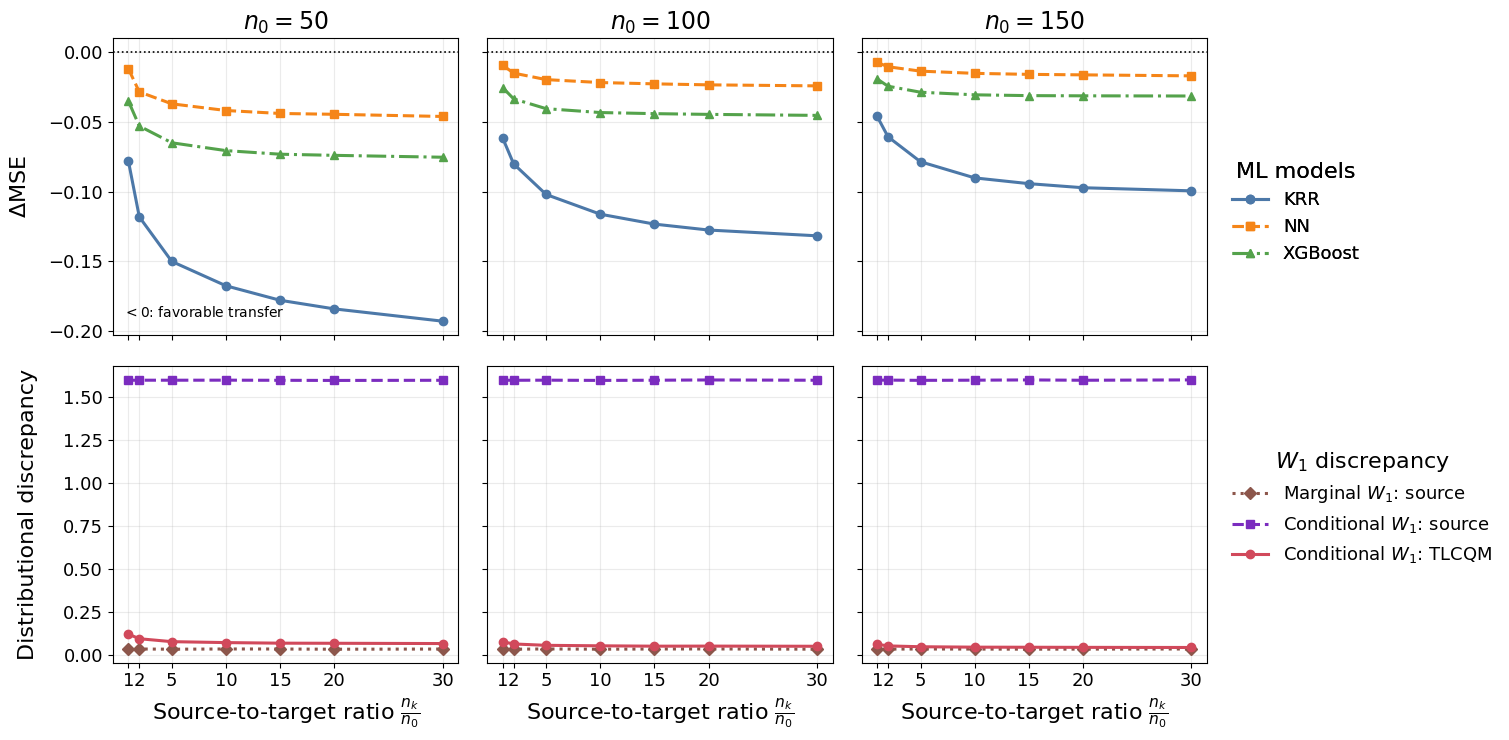

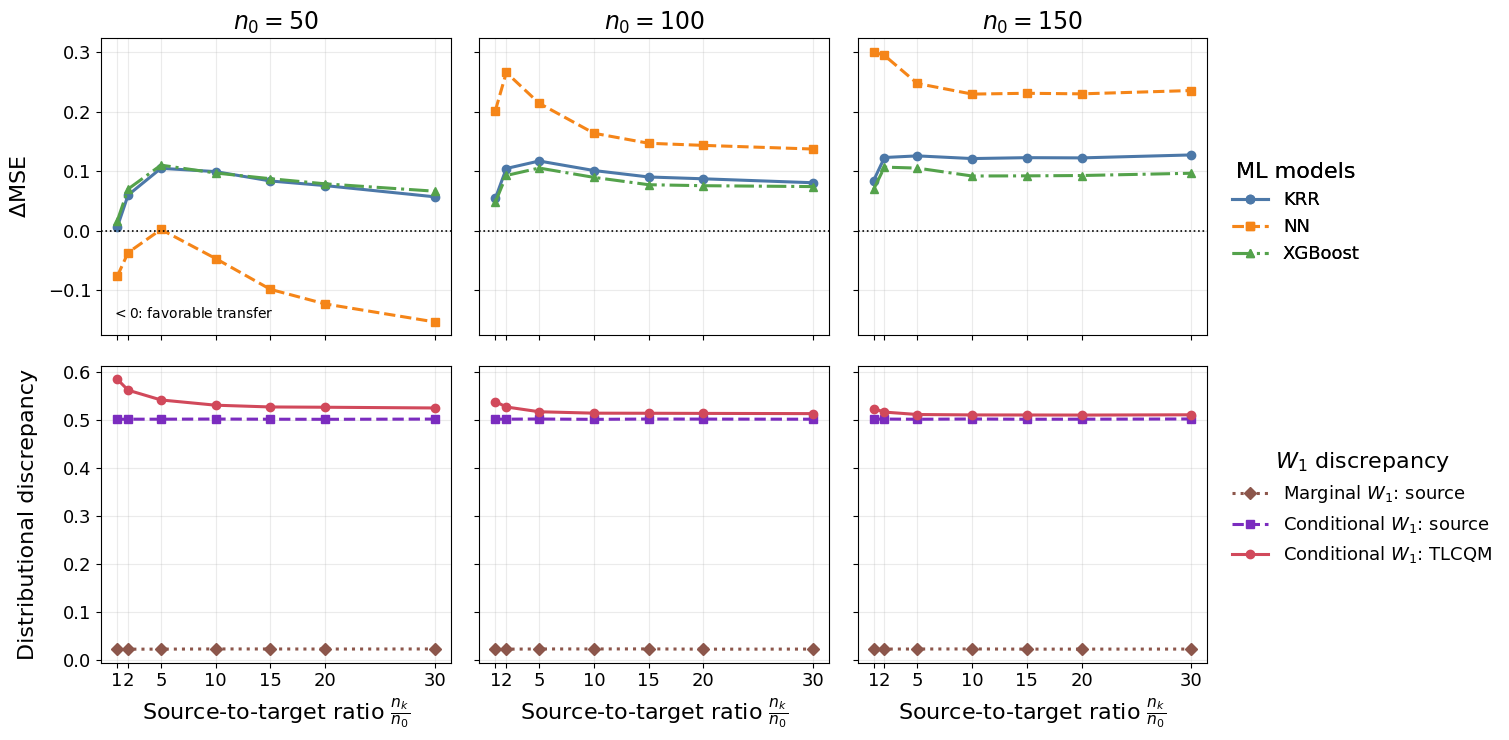

In [51]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D


# ============================================================
# Load and reshape the diagnostic results
# ============================================================
res = pd.read_csv("diag.csv")

# Recompute for safety
res["source_target_ratio"] = (
    res["source_size"] / res["target_size"]
)

id_columns = [
    "Scenario",
    "source_size",
    "target_size",
    "source_target_ratio",
]

wide = (
    res.pivot_table(
        index=id_columns,
        columns="Metric",
        values="Value",
        aggfunc="mean",
    )
    .reset_index()
)

wide.columns.name = None


# ============================================================
# Construct Delta MSE
# Negative values indicate improvement over target-only learning
# ============================================================
models = ["KRR", "NN", "XGBoost"]

for model in models:
    wide[f"Delta_MSE_{model}"] = (
        wide[f"MSE_{model}_TLCQM"]
        - wide[f"MSE_{model}_Target_Only"]
    )


# ============================================================
# Plot configuration
# ============================================================
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 17,
    "axes.labelsize": 16,
    "legend.fontsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

target_sizes = sorted(wide["target_size"].unique())
ratios = sorted(wide["source_target_ratio"].unique())

model_markers = {
    "KRR": "o",
    "NN": "s",
    "XGBoost": "^",
}

model_linestyles = {
    "KRR": "-",
    "NN": "--",
    "XGBoost": "-.",
}

discrepancy_metrics = {
    "Marginal_W1_Source1": r"Marginal $W_1$: source",
    "Conditional_W1_Source1": r"Conditional $W_1$: source",
    "Conditional_W1_TLCQM": r"Conditional $W_1$: TLCQM",
}

discrepancy_markers = {
    "Marginal_W1_Source1": "D",
    "Conditional_W1_Source1": "s",
    "Conditional_W1_TLCQM": "o",
}

discrepancy_linestyles = {
    "Marginal_W1_Source1": ":",
    "Conditional_W1_Source1": "--",
    "Conditional_W1_TLCQM": "-",
}

# Shared palettes across both diagnostic scenarios
model_colors = {
    "KRR": "#4C78A8",       # blue
    "NN": "#F58518",        # orange
    "XGBoost": "#54A24B",   # green
}

discrepancy_colors = {
    "Marginal_W1_Source1": "tab:brown",     
    "Conditional_W1_Source1": "#7B2CBF",   # purple
    "Conditional_W1_TLCQM": "#D1495B",     # rose
}

scenario_settings = {
    "reversed": {
        "title": "Reversed relationship",
        "model_colors": model_colors,
        "discrepancy_colors": discrepancy_colors,
        "output": "Diagnostic_Reversed.pdf",
    },
    "outside_span": {
        "title": "Outside affine span",
        "model_colors": model_colors,
        "discrepancy_colors": discrepancy_colors,
        "output": "Diagnostic_Outside_Span.pdf",
    },
}


# ============================================================
# Plotting function
# ============================================================
def plot_diagnostic_scenario(
    data: pd.DataFrame,
    scenario: str,
    output_dir: str | Path = "./Figures",
) -> None:
    """
    Create one 2 x 3 diagnostic figure for a single scenario.

    Top row:
        Delta MSE = MSE_TLCQM - MSE_Target-only.

    Bottom row:
        Marginal and conditional Wasserstein discrepancies.
    """
    if scenario not in scenario_settings:
        raise ValueError(
            f"Unknown scenario {scenario!r}. "
            f"Available scenarios: {list(scenario_settings)}"
        )

    settings = scenario_settings[scenario]
    scenario_data = data[data["Scenario"] == scenario].copy()

    if scenario_data.empty:
        raise ValueError(f"No observations found for scenario {scenario!r}.")

    fig, axes = plt.subplots(
        nrows=2,
        ncols=len(target_sizes),
        figsize=(15, 8),
        sharex="col",
        sharey="row",
    )

    # --------------------------------------------------------
    # Plot each target sample size
    # --------------------------------------------------------
    for col, target_size in enumerate(target_sizes):
        panel = (
            scenario_data[
                scenario_data["target_size"] == target_size
            ]
            .sort_values("source_target_ratio")
        )

        ax_mse = axes[0, col]
        ax_dist = axes[1, col]

        # ----------------------------------------------------
        # Top row: Delta MSE
        # ----------------------------------------------------
        for model in models:
            ax_mse.plot(
                panel["source_target_ratio"],
                panel[f"Delta_MSE_{model}"],
                color=settings["model_colors"][model],
                marker=model_markers[model],
                linestyle=model_linestyles[model],
                linewidth=2.2,
                markersize=6,
            )

        # Zero separates favorable and negative transfer
        ax_mse.axhline(
            y=0,
            color="black",
            linestyle=":",
            linewidth=1.2,
        )

        ax_mse.set_title(rf"$n_0={target_size}$")
        ax_mse.grid(True, alpha=0.25)

        # ----------------------------------------------------
        # Bottom row: distributional discrepancies
        # ----------------------------------------------------
        for metric in discrepancy_metrics:
            ax_dist.plot(
                panel["source_target_ratio"],
                panel[metric],
                color=settings["discrepancy_colors"][metric],
                marker=discrepancy_markers[metric],
                linestyle=discrepancy_linestyles[metric],
                linewidth=2.2,
                markersize=6,
            )

        ax_dist.set_xlabel(r"Source-to-target ratio $\frac{n_k}{n_0}$")
        ax_dist.set_xticks(ratios)
        ax_dist.set_xticklabels([f"{ratio:g}" for ratio in ratios])
        ax_dist.grid(True, alpha=0.25)

        # Uncomment for a log-scaled x-axis:
        # ax_mse.set_xscale("log")
        # ax_dist.set_xscale("log")
        # ax_dist.set_yscale("log")

    axes[0, 0].set_ylabel(
        r"$\Delta$MSE",
#         "\n"
#         r"$\mathrm{MSE}_{\mathrm{TLCQM}}"
#         r"-\mathrm{MSE}_{\mathrm{Target}}$"
        labelpad=13
    )
    axes[1, 0].set_ylabel(r"Distributional discrepancy", labelpad=18)

    # Lightly mark the interpretation of Delta MSE
    axes[0, 0].text(
        0.03,
        0.05,
        r"$<0$: favorable transfer",
        transform=axes[0, 0].transAxes,
        fontsize=10,
        verticalalignment="bottom",
    )

    # --------------------------------------------------------
    # Shared legends
    # --------------------------------------------------------
    model_handles = [
        Line2D(
            [0],
            [0],
            color=settings["model_colors"][model],
            marker=model_markers[model],
            linestyle=model_linestyles[model],
            linewidth=2.2,
            markersize=6,
            label=model,
        )
        for model in models
    ]

    discrepancy_handles = [
        Line2D(
            [0],
            [0],
            color=settings["discrepancy_colors"][metric],
            marker=discrepancy_markers[metric],
            linestyle=discrepancy_linestyles[metric],
            linewidth=2.2,
            markersize=6,
            label=label,
        )
        for metric, label in discrepancy_metrics.items()
    ]

    model_legend = fig.legend(
        handles=model_handles,
        # title=r"Prediction: $\Delta$MSE",
        title="ML models",
        loc="upper left",
        bbox_to_anchor=(0.82, 0.76),
        frameon=False,
    )

    fig.legend(
        handles=discrepancy_handles,
        # title="Distributional discrepancy",
        title="$W_1$ discrepancy",
        loc="upper left",
        bbox_to_anchor=(0.82, 0.4),
        frameon=False,
    )

    fig.add_artist(model_legend)

    # Leave room on the right for the shared legends
    fig.tight_layout(rect=[0, 0, 0.83, 0.96])

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    pdf_path = output_dir / settings["output"]
    
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)


# ============================================================
# Generate the two figures
# ============================================================
plot_diagnostic_scenario(
    wide,
    scenario="reversed",
    output_dir="./Figures",
)

plot_diagnostic_scenario(
    wide,
    scenario="outside_span",
    output_dir="./Figures",
)